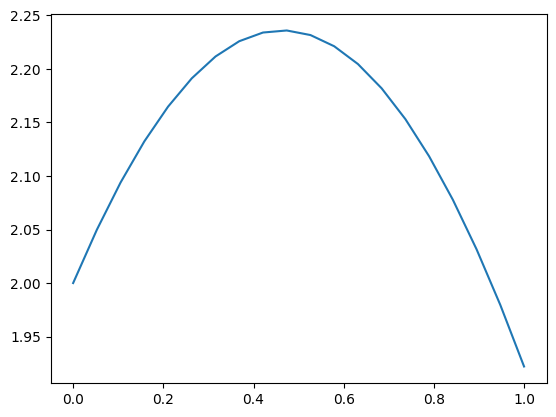

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



def f(x):
    return np.sin(x)

def phi(x):
    return (2*np.cos(x) + np.sin(x))


mu1 = 1.2
mu2 = 1.

L=1.0; N=20; T=1.0; J=20

x = np.linspace(0, L, N)

plt.plot(x, phi(x))

y = np.zeros((J+1, N+1))

a[i] = 1 = b[i]
c[i] = 2 + r + p[j]*h**2*p[j-1]
d[i] = r*y[j-1]

y[:][0] = mu1
y[:][N] = mu2











Решение обратной задачи для уравнения теплопроводности
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 0
Шаг 0: ошибка переопределения = 2.19e-02
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 1
Шаг 1: ошибка переопределения = 4.31e-02
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 2
Шаг 2: ошибка переопределения = 6.38e-02
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 3
Шаг 3: ошибка переопределения = 8.36e-02
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 4
Шаг 4: ошибка переопределения = 1.02e-01
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 5
Шаг 5: ошибка переопределения = 1.20e-01
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 6
Шаг 6: ошибка переопределения = 1.35e-01
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 7
Шаг 7: ошибка переопределения = 1.49e-01
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 8
Шаг 8: ошибка переопределения = 1.61e-01
Предупреждение: v[25] = 0.00e+00 близко к 0 на шаге 9
Шаг 9: ошибка переопределения = 1.72

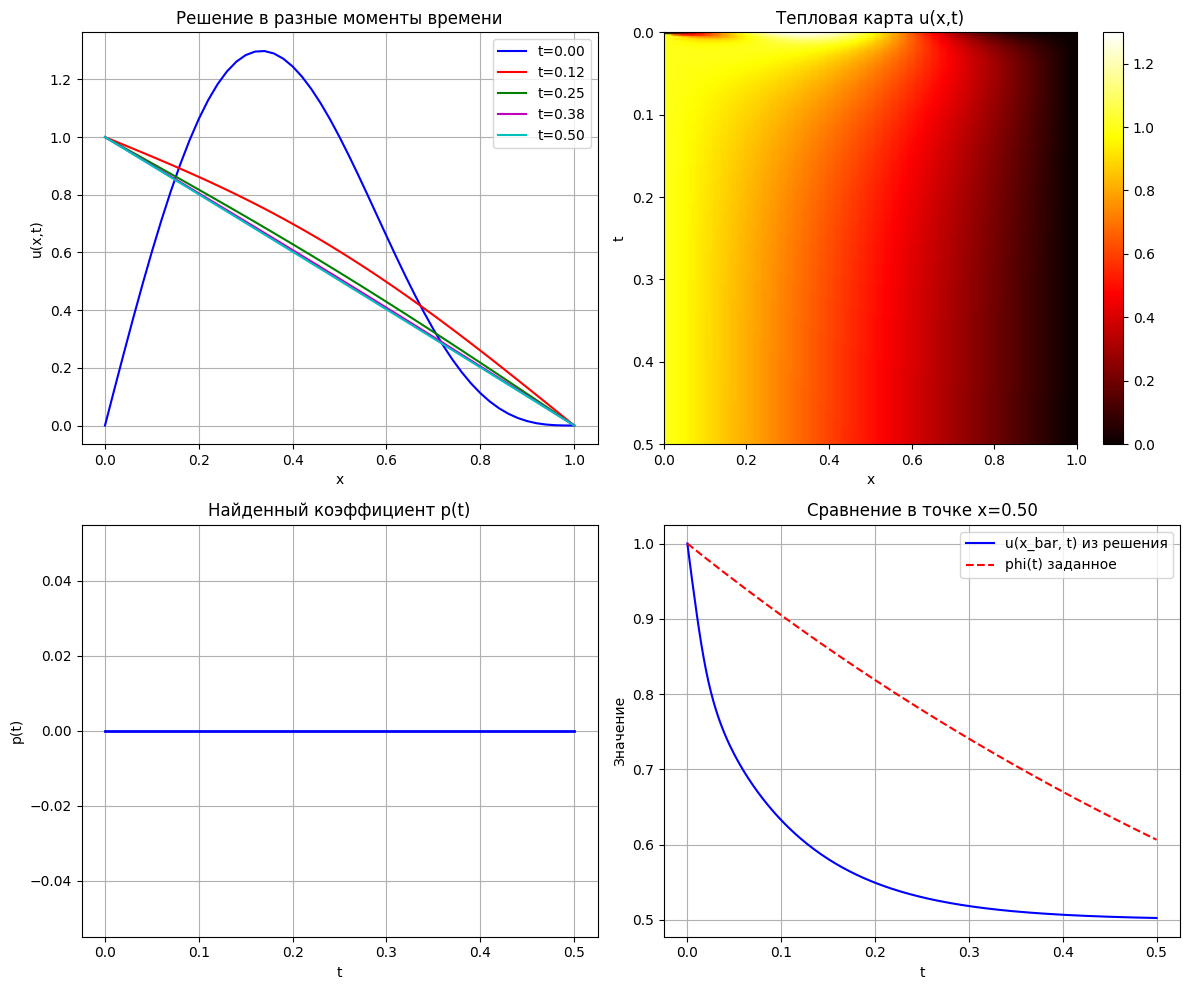

АНАЛИЗ ТОЧНОСТИ
Средняя ошибка в условии переопределения: 2.11e-01
Максимальная ошибка: 2.80e-01
Шаг по пространству h = 0.0200
Шаг по времени τ = 0.0025


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

class InverseHeatSolver:
    """
    Решение обратной задачи для уравнения теплопроводности
    с неизвестным источником p(t)
    """
    
    def __init__(self, l=1.0, t_max=1.0, N=50, J=100):
        """
        Инициализация параметров
        
        Parameters:
        -----------
        l : float
            Длина стержня
        t_max : float
            Максимальное время
        N : int
            Количество пространственных узлов
        J : int
            Количество временных узлов
        """
        self.l = l
        self.t_max = t_max
        self.N = N
        self.J = J
        
        # Шаги сетки
        self.h = l / N
        self.tau = t_max / J
        
        # Координаты
        self.x = np.linspace(0, l, N+1)
        self.t = np.linspace(0, t_max, J+1)
        
        # Параметр для схемы Кранка-Николсона
        self.r = 2 * self.h**2 / self.tau
        
        # Место переопределения (по умолчанию середина)
        self.n = N // 2  # индекс точки переопределения
        self.x_bar = self.x[self.n]
        
        # Инициализация массивов
        self.y = np.zeros((N+1, J+1))  # решение
        self.p = np.zeros(J+1)         # неизвестный коэффициент
        self.z = np.zeros(N+1)         # вспомогательная функция z
        self.v = np.zeros(N+1)         # вспомогательная функция v
        
    def set_initial_conditions(self, u0_func, mu1_func, mu2_func, phi_func):
        """
        Задание начальных и граничных условий
        
        Parameters:
        -----------
        u0_func : function
            Начальное условие u(x,0) = u0(x)
        mu1_func : function
            Граничное условие u(0,t) = mu1(t)
        mu2_func : function
            Граничное условие u(l,t) = mu2(t)
        phi_func : function
            Условие переопределения u(x_bar, t) = phi(t)
        """
        self.u0_func = u0_func
        self.mu1_func = mu1_func
        self.mu2_func = mu2_func
        self.phi_func = phi_func
        
        # Начальное условие
        for i in range(self.N+1):
            self.y[i, 0] = u0_func(self.x[i])
        
        # Условие переопределения при t=0
        self.phi_vals = np.array([phi_func(t) for t in self.t])
        
        # Граничные условия
        self.mu1_vals = np.array([mu1_func(t) for t in self.t])
        self.mu2_vals = np.array([mu2_func(t) for t in self.t])
        
        # Начальное значение p(0) из условия согласования
        self.p[0] = 0.0  # начальное предположение
    
    def solve(self):
        """
        Решение обратной задачи
        """
        # Проходим по временным слоям
        for j in range(self.J):
            # Текущий временной слой
            t_curr = self.t[j]
            t_next = self.t[j+1]
            
            # Известные значения на текущем слое
            y_curr = self.y[:, j].copy()
            p_curr = self.p[j]
            
            # Решаем систему для z и v
            self._solve_z_v_system(y_curr, p_curr, j)
            
            # Находим p на следующем слое из условия переопределения
            phi_next = self.phi_vals[j+1]
            
            # Проверка деления на ноль
            if abs(self.v[self.n]) < 1e-10:
                # Если v[n] близко к нулю, используем предыдущее значение p
                p_next = p_curr
                print(f"Предупреждение: v[{self.n}] = {self.v[self.n]:.2e} близко к 0 на шаге {j}")
            else:
                p_next = (phi_next - self.z[self.n]) / self.v[self.n]
            
            # Обновляем p
            self.p[j+1] = p_next
            
            # Вычисляем решение на следующем слое
            self.y[:, j+1] = self.z + p_next * self.v
            
            # Устанавливаем граничные условия
            self.y[0, j+1] = self.mu1_vals[j+1]
            self.y[self.N, j+1] = self.mu2_vals[j+1]
            
            # Проверка условия переопределения
            error = abs(self.y[self.n, j+1] - phi_next)
            if error > 0.01:
                print(f"Шаг {j}: ошибка переопределения = {error:.2e}")
    
    def _solve_z_v_system(self, y_curr, p_curr, j):
        """
        Решение систем для z и v на временном слое j+1
        
        Система имеет вид:
        a_i * u_{i-1} - c_i * u_i + b_i * u_{i+1} = d_i
        """
        N = self.N
        h = self.h
        tau = self.tau
        r = self.r
        
        # Коэффициенты для системы
        a = 1.0
        b = 1.0
        
        # Векторы для прогонки
        alpha_z = np.zeros(N+1)
        beta_z = np.zeros(N+1)
        alpha_v = np.zeros(N+1)
        beta_v = np.zeros(N+1)
        
        # Граничные условия для z
        z0 = self.mu1_vals[j+1]  # u(0, t_{j+1})
        zN = self.mu2_vals[j+1]  # u(l, t_{j+1})
        
        # Граничные условия для v
        v0 = 0.0
        vN = 0.0
        
        # Прямой ход прогонки для z
        # Начальные условия
        alpha_z[1] = 0.0
        beta_z[1] = z0
        
        # Коэффициенты для внутренних точек
        for i in range(1, N):
            # Коэффициенты
            c_i = 2 + r + p_curr * h**2 * self.p[max(0, j-1)]
            
            # Правая часть для z
            d_i_z = r * y_curr[i] + (y_curr[i+1] - 2*y_curr[i] + y_curr[i-1]) + h**2 * self.p[max(0, j-1)] * y_curr[i]
            
            if i == 1:
                denom = c_i
                alpha_z[i+1] = b / denom
                beta_z[i+1] = (d_i_z + a * beta_z[i]) / denom
            else:
                denom = c_i - a * alpha_z[i]
                alpha_z[i+1] = b / denom
                beta_z[i+1] = (d_i_z + a * beta_z[i]) / denom
        
        # Прямой ход прогонки для v
        alpha_v[1] = 0.0
        beta_v[1] = v0
        
        for i in range(1, N):
            c_i = 2 + r + p_curr * h**2 * self.p[max(0, j-1)]
            
            if i == 1:
                denom = c_i
                alpha_v[i+1] = b / denom
                beta_v[i+1] = a * beta_v[i] / denom
            else:
                denom = c_i - a * alpha_v[i]
                alpha_v[i+1] = b / denom
                beta_v[i+1] = a * beta_v[i] / denom
        
        # Обратный ход для z
        self.z[N] = zN
        for i in range(N-1, -1, -1):
            if i == N-1:
                self.z[i] = beta_z[i+1]
            else:
                self.z[i] = alpha_z[i+1] * self.z[i+1] + beta_z[i+1]
        
        # Обратный ход для v
        self.v[N] = vN
        for i in range(N-1, -1, -1):
            if i == N-1:
                self.v[i] = beta_v[i+1]
            else:
                self.v[i] = alpha_v[i+1] * self.v[i+1] + beta_v[i+1]
    
    def plot_solution(self):
        """
        Визуализация решения
        """
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # 1. Решение u(x,t) в разные моменты времени
        ax = axes[0, 0]
        time_indices = [0, self.J//4, self.J//2, 3*self.J//4, self.J]
        colors = ['b', 'r', 'g', 'm', 'c']
        
        for idx, color in zip(time_indices, colors):
            t_val = self.t[idx]
            ax.plot(self.x, self.y[:, idx], color=color, 
                   label=f't={t_val:.2f}')
        
        ax.set_xlabel('x')
        ax.set_ylabel('u(x,t)')
        ax.set_title('Решение в разные моменты времени')
        ax.legend()
        ax.grid(True)
        
        # 2. Тепловая карта u(x,t)
        ax = axes[0, 1]
        im = ax.imshow(self.y.T, aspect='auto', extent=[0, self.l, self.t_max, 0],
                      cmap='hot', origin='upper')
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        ax.set_title('Тепловая карта u(x,t)')
        plt.colorbar(im, ax=ax)
        
        # 3. Найденный коэффициент p(t)
        ax = axes[1, 0]
        ax.plot(self.t, self.p, 'b-', linewidth=2)
        ax.set_xlabel('t')
        ax.set_ylabel('p(t)')
        ax.set_title('Найденный коэффициент p(t)')
        ax.grid(True)
        
        # 4. Сравнение условия переопределения
        ax = axes[1, 1]
        u_at_x_bar = self.y[self.n, :]
        ax.plot(self.t, u_at_x_bar, 'b-', label='u(x_bar, t) из решения')
        ax.plot(self.t, self.phi_vals, 'r--', label='phi(t) заданное')
        ax.set_xlabel('t')
        ax.set_ylabel('Значение')
        ax.set_title(f'Сравнение в точке x={self.x_bar:.2f}')
        ax.legend()
        ax.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def calculate_error(self):
        """
        Вычисление ошибки
        """
        # Ошибка в условии переопределения
        error_overdetermination = np.abs(self.y[self.n, :] - self.phi_vals)
        
        # Средняя ошибка
        mean_error = np.mean(error_overdetermination[1:])  # исключаем t=0
        
        print("="*50)
        print("АНАЛИЗ ТОЧНОСТИ")
        print("="*50)
        print(f"Средняя ошибка в условии переопределения: {mean_error:.2e}")
        print(f"Максимальная ошибка: {np.max(error_overdetermination):.2e}")
        print(f"Шаг по пространству h = {self.h:.4f}")
        print(f"Шаг по времени τ = {self.tau:.4f}")
        print("="*50)
        
        return mean_error

# Пример использования с тестовыми данными
def example_solution():
    """
    Пример решения обратной задачи с тестовыми данными
    """
    # Параметры задачи
    l = 1.0
    t_max = 0.5
    N = 50
    J = 200
    
    # Создаем решатель
    solver = InverseHeatSolver(l=l, t_max=t_max, N=N, J=J)
    
    # Задаем условия (примерные функции)
    def u0(x):
        """Начальное условие"""
        return np.sin(np.pi * x) + 0.5 * np.sin(2 * np.pi * x)
    
    def mu1(t):
        """Граничное условие при x=0"""
        return 0.0
    
    def mu2(t):
        """Граничное условие при x=l"""
        return 0.0
    
    # Задаем условие переопределения
    # Для теста предположим, что p(t) = sin(2πt)
    def exact_p(t):
        return np.sin(2 * np.pi * t)
    
    def phi(t):
        """Условие переопределения"""
        # Это должна быть функция, которую мы "измеряем" в точке x_bar
        # Для теста используем аналитическое решение
        x_bar = solver.x_bar
        # Простое тестовое выражение
        return np.exp(-t) * np.sin(np.pi * x_bar)
    
    # Устанавливаем условия
    solver.set_initial_conditions(u0, mu1, mu2, phi)
    
    # Решаем задачу
    solver.solve()
    
    # Визуализируем результаты
    solver.plot_solution()
    
    # Вычисляем ошибку
    solver.calculate_error()
    
    return solver

# Дополнительные функции для анализа
def convergence_study():
    """
    Исследование сходимости метода
    """
    N_values = [20, 40, 80, 160]
    errors = []
    
    for N in N_values:
        J = N * 2  # сохраняем отношение временных и пространственных шагов
        solver = InverseHeatSolver(l=1.0, t_max=0.5, N=N, J=J)
        
        # Простые тестовые условия
        def u0(x):
            return np.sin(np.pi * x)
        
        def mu1(t):
            return 0.0
        
        def mu2(t):
            return 0.0
        
        def phi(t):
            return np.exp(-t) * np.sin(np.pi * solver.x_bar)
        
        solver.set_initial_conditions(u0, mu1, mu2, phi)
        solver.solve()
        
        error = solver.calculate_error()
        errors.append(error)
    
    # График сходимости
    plt.figure(figsize=(8, 6))
    h_values = [1.0 / N for N in N_values]
    plt.loglog(h_values, errors, 'bo-', label='Ошибка')
    plt.loglog(h_values, [h**2 for h in h_values], 'r--', label='O(h²)')
    plt.xlabel('Шаг по пространству h')
    plt.ylabel('Средняя ошибка')
    plt.title('Исследование сходимости')
    plt.legend()
    plt.grid(True, which="both", ls="-")
    plt.show()

if __name__ == "__main__":
    # Запуск примера
    print("Решение обратной задачи для уравнения теплопроводности")
    print("="*60)
    
    # Пример с тестовыми данными
    solver = example_solution()
    
    # Исследование сходимости (опционально)
    # convergence_study()

ТЕСТОВАЯ ЗАДАЧА 1
Параметры сетки:
  h = 0.0200, τ = 0.0050, r = 0.1600
  Точка переопределения: x=0.5000 (индекс n=25)
АНАЛИЗ ТОЧНОСТИ РЕШЕНИЯ
Максимальная ошибка в условии переопределения: 0.00e+00
Средняя ошибка (t>0): 0.00e+00
Шаги сетки: h = 0.0200, τ = 0.0050
Параметр r = 0.1600


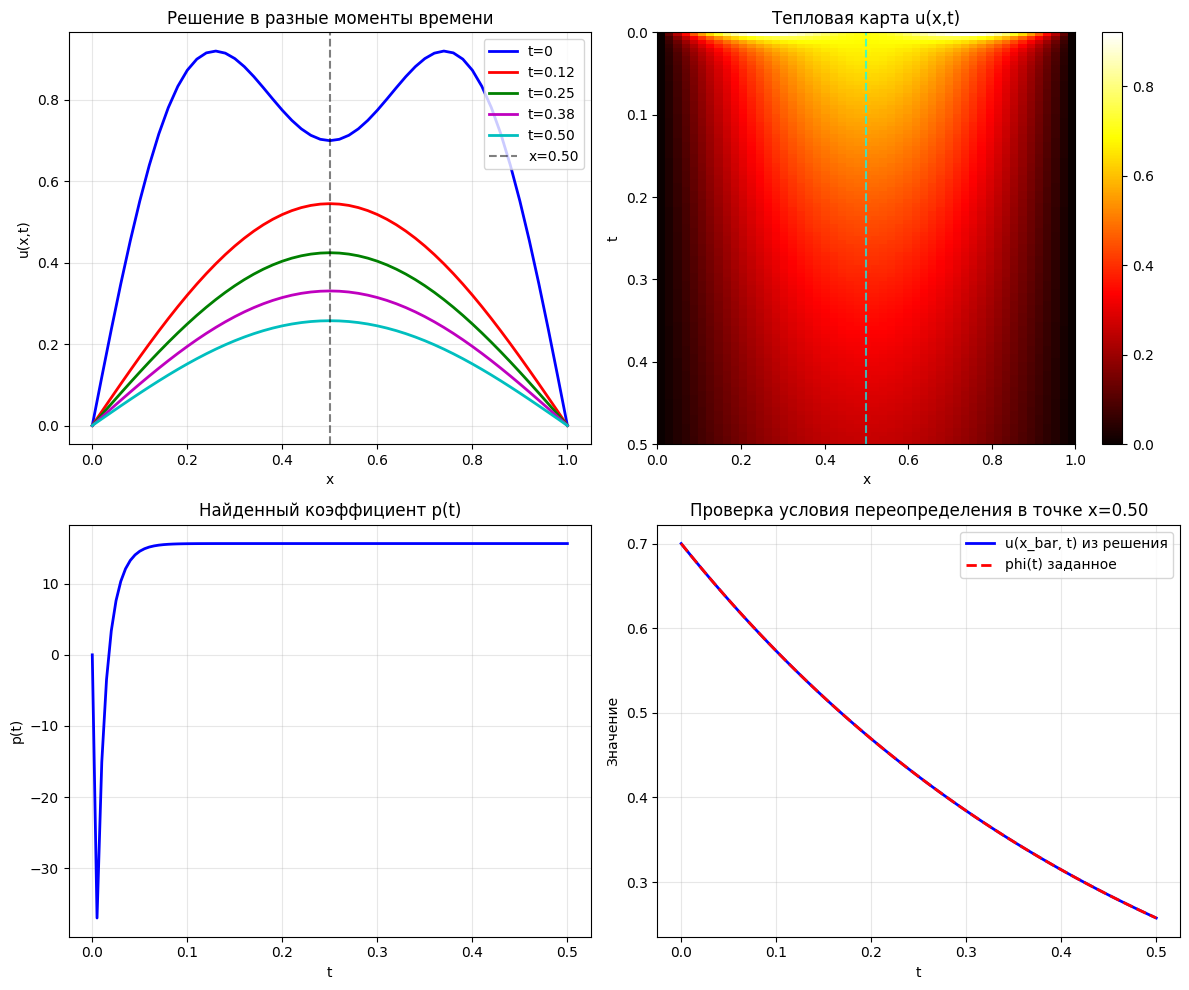


ТЕСТОВАЯ ЗАДАЧА 2
Параметры сетки:
  h = 0.0167, τ = 0.0020, r = 0.2778
  Точка переопределения: x=0.3000 (индекс n=18)
АНАЛИЗ ТОЧНОСТИ РЕШЕНИЯ
Максимальная ошибка в условии переопределения: 0.00e+00
Средняя ошибка (t>0): 0.00e+00
Шаги сетки: h = 0.0167, τ = 0.0020
Параметр r = 0.2778


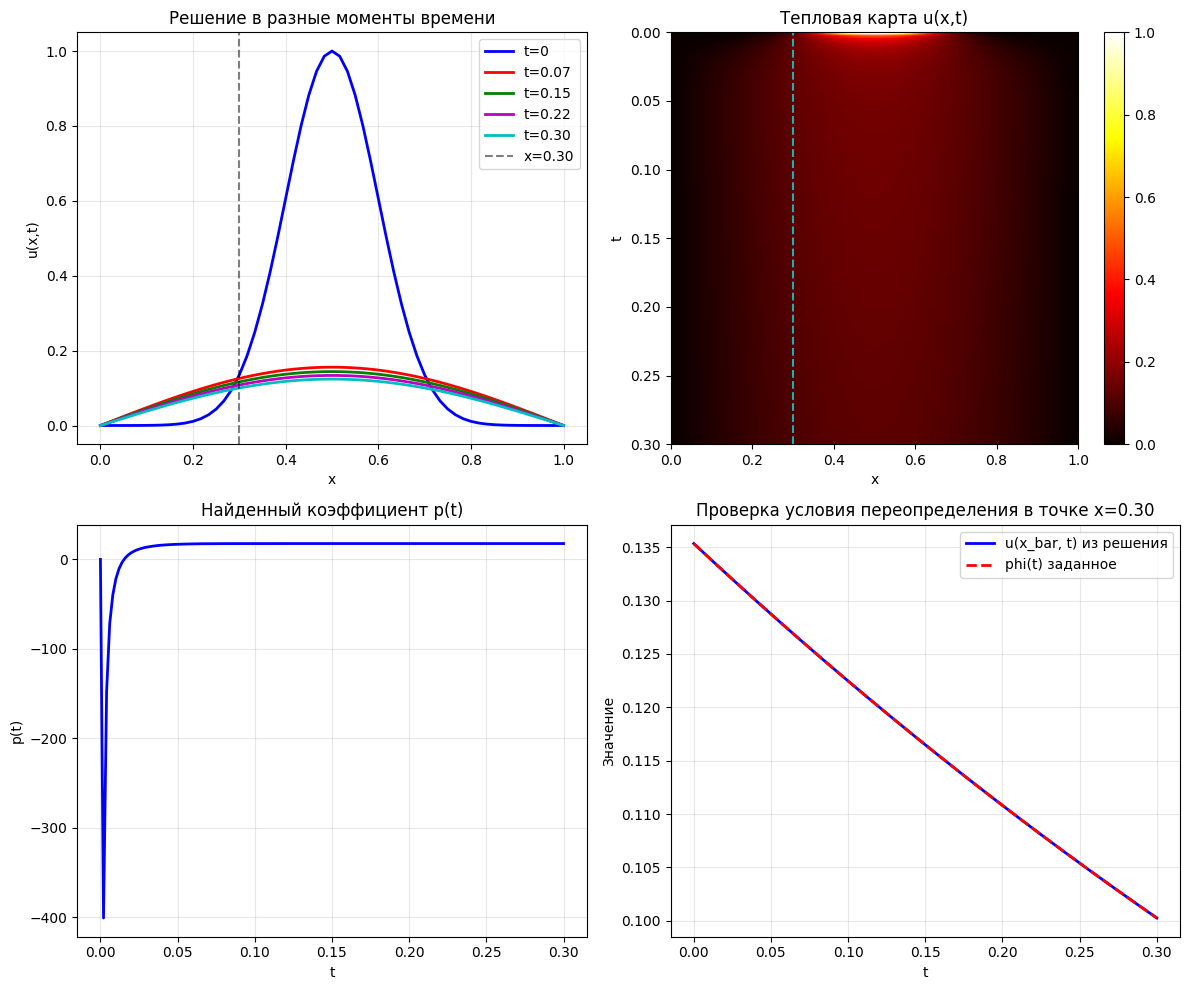

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

class InverseHeatProblem:
    """
    Решение обратной задачи для уравнения теплопроводности
    с использованием схемы Кранка-Николсона
    """
    
    def __init__(self, l=1.0, t_max=0.5, N=50, J=100, x_bar=0.5):
        """
        Инициализация параметров
        
        Parameters:
        -----------
        l : float
            Длина стержня
        t_max : float
            Максимальное время
        N : int
            Количество пространственных узлов
        J : int
            Количество временных узлов
        x_bar : float
            Точка переопределения (должна быть внутри (0,l))
        """
        self.l = l
        self.t_max = t_max
        self.N = N
        self.J = J
        
        # Проверяем, что x_bar внутри интервала
        if x_bar <= 0 or x_bar >= l:
            raise ValueError(f"x_bar должно быть внутри (0, {l})")
        
        # Шаги сетки
        self.h = l / N
        self.tau = t_max / J
        
        # Координаты
        self.x = np.linspace(0, l, N+1)
        self.t = np.linspace(0, t_max, J+1)
        
        # Индекс точки переопределения
        self.n = int(np.round(x_bar / self.h))
        self.x_bar = self.x[self.n]
        
        # Параметр r
        self.r = 2 * self.h**2 / self.tau
        
        # Инициализация массивов
        self.y = np.zeros((N+1, J+1))  # решение u(x,t)
        self.p = np.zeros(J+1)         # неизвестный коэффициент p(t)
        
        print(f"Параметры сетки:")
        print(f"  h = {self.h:.4f}, τ = {self.tau:.4f}, r = {self.r:.4f}")
        print(f"  Точка переопределения: x={self.x_bar:.4f} (индекс n={self.n})")
    
    def set_conditions(self, u0_func, mu1_func, mu2_func, phi_func):
        """
        Задание начальных и граничных условий
        
        Parameters:
        -----------
        u0_func : function
            Начальное условие u(x,0) = u0(x)
        mu1_func : function
            Граничное условие u(0,t) = mu1(t)
        mu2_func : function
            Граничное условие u(l,t) = mu2(t)
        phi_func : function
            Условие переопределения u(x_bar, t) = phi(t)
        """
        # Сохраняем функции
        self.u0_func = u0_func
        self.mu1_func = mu1_func
        self.mu2_func = mu2_func
        self.phi_func = phi_func
        
        # Вычисляем значения функций на сетке
        self.mu1_vals = np.array([mu1_func(t) for t in self.t])
        self.mu2_vals = np.array([mu2_func(t) for t in self.t])
        self.phi_vals = np.array([phi_func(t) for t in self.t])
        
        # Начальное условие
        for i in range(self.N+1):
            self.y[i, 0] = u0_func(self.x[i])
        
        # Проверка согласования
        phi0 = phi_func(0)
        u0_at_xbar = u0_func(self.x_bar)
        if abs(phi0 - u0_at_xbar) > 1e-10:
            print(f"Предупреждение: условие согласования нарушено")
            print(f"  phi(0) = {phi0:.6f}, u0(x_bar) = {u0_at_xbar:.6f}")
        
        # Начальное значение p(0) = 0
        self.p[0] = 0.0
    
    def _solve_tridiagonal(self, a, c, b, d):
        """
        Решение трехдиагональной системы методом прогонки
        
        Система: a[i]*x[i-1] + c[i]*x[i] + b[i]*x[i+1] = d[i]
        для i = 0, ..., N, с граничными условиями на x[0] и x[N]
        """
        n = len(d)
        # Прямой ход прогонки
        alpha = np.zeros(n)
        beta = np.zeros(n)
        
        # Начальные прогоночные коэффициенты
        alpha[1] = -b[0] / c[0]
        beta[1] = d[0] / c[0]
        
        # Прямой ход для внутренних точек
        for i in range(1, n-1):
            denom = c[i] + a[i] * alpha[i]
            alpha[i+1] = -b[i] / denom
            beta[i+1] = (d[i] - a[i] * beta[i]) / denom
        
        # Обратный ход
        x = np.zeros(n)
        x[n-1] = (d[n-1] - a[n-1] * beta[n-1]) / (c[n-1] + a[n-1] * alpha[n-1])
        
        for i in range(n-2, -1, -1):
            x[i] = alpha[i+1] * x[i+1] + beta[i+1]
        
        return x
    
    def solve(self):
        """
        Решение обратной задачи по алгоритму (10)-(12)
        """
        N = self.N
        h = self.h
        r = self.r
        
        # Основной цикл по временным слоям
        for j in range(1, self.J+1):
            t_j = self.t[j]
            
            # Известные значения на предыдущем слое
            y_prev = self.y[:, j-1].copy()
            p_prev = self.p[j-1]
            
            # 1. Решаем систему для z (уравнение 10)
            # Матрица системы для z (без учета граничных условий)
            size = N-1  # внутренние точки
            
            # Коэффициенты трехдиагональной матрицы
            a = np.ones(size)  # коэффициент при z[i-1]
            c = np.full(size, -(2 + r))  # коэффициент при z[i] (c_i = -(2+r))
            b = np.ones(size)  # коэффициент при z[i+1]
            
            # Правая часть d_i = -d_i_bar
            d = np.zeros(size)
            for i in range(1, N):
                idx = i-1  # индекс в массиве внутренних точек
                d_i_bar = r * y_prev[i] + (y_prev[i+1] - 2*y_prev[i] + y_prev[i-1])
                d[idx] = -d_i_bar
            
            # Учет граничных условий z_0 = mu1(t_j), z_N = mu2(t_j)
            d[0] -= self.mu1_vals[j]  # при i=1: уравнение содержит z_0 = mu1
            d[-1] -= self.mu2_vals[j]  # при i=N-1: уравнение содержит z_N = mu2
            
            # Решаем систему для внутренних точек z[1:N]
            z_inner = self._solve_tridiagonal(a, c, b, d)
            
            # Полный вектор z
            z = np.zeros(N+1)
            z[0] = self.mu1_vals[j]
            z[N] = self.mu2_vals[j]
            z[1:N] = z_inner
            
            # 2. Решаем систему для v (уравнение 11)
            # Матрица та же самая: a_i = 1, c_i = -(2+r), b_i = 1
            # Правая часть: -h^2 * y_i^{j-1}
            d_v = np.zeros(size)
            for i in range(1, N):
                idx = i-1
                d_v[idx] = -h**2 * y_prev[i]
            
            # Граничные условия v_0 = 0, v_N = 0
            # Учет граничных условий (v_0 и v_N уже учтены как 0 в правых частях)
            # На самом деле, поскольку граничные условия нулевые,
            # они не меняют правую часть для первой и последней внутренней точки
            
            # Решаем систему для внутренних точек v[1:N]
            v_inner = self._solve_tridiagonal(a, c, b, d_v)
            
            # Полный вектор v
            v = np.zeros(N+1)
            v[0] = 0.0
            v[N] = 0.0
            v[1:N] = v_inner
            
            # 3. Находим p^j (уравнение 12)
            phi_j = self.phi_vals[j]
            z_n = z[self.n]
            v_n = v[self.n]
            
            # Проверка деления на ноль
            if abs(v_n) < 1e-12:
                print(f"Предупреждение: v[{self.n}] = {v_n:.2e} близко к 0 на шаге {j}")
                # Используем предыдущее значение p
                p_j = self.p[j-1]
            else:
                p_j = (phi_j - z_n) / v_n
            
            self.p[j] = p_j
            
            # 4. Вычисляем y^j = z + p^j * v
            self.y[:, j] = z + p_j * v
            
            # Проверка точности выполнения условия переопределения
            y_n_j = self.y[self.n, j]
            error = abs(y_n_j - phi_j)
            if error > 1e-8:
                print(f"Шаг {j}: y[{self.n},{j}] = {y_n_j:.8f}, phi[{j}] = {phi_j:.8f}, ошибка = {error:.2e}")
    
    def plot_solution(self):
        """
        Визуализация результатов
        """
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # 1. Решение u(x,t) в разные моменты времени
        ax = axes[0, 0]
        time_indices = [0, self.J//4, self.J//2, 3*self.J//4, self.J]
        colors = ['b', 'r', 'g', 'm', 'c']
        labels = ['t=0', f't={self.t[self.J//4]:.2f}', f't={self.t[self.J//2]:.2f}',
                 f't={self.t[3*self.J//4]:.2f}', f't={self.t[self.J]:.2f}']
        
        for idx, color, label in zip(time_indices, colors, labels):
            ax.plot(self.x, self.y[:, idx], color=color, linewidth=2, label=label)
        
        # Вертикальная линия в точке переопределения
        ax.axvline(x=self.x_bar, color='k', linestyle='--', alpha=0.5, label=f'x={self.x_bar:.2f}')
        
        ax.set_xlabel('x')
        ax.set_ylabel('u(x,t)')
        ax.set_title('Решение в разные моменты времени')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 2. Тепловая карта u(x,t)
        ax = axes[0, 1]
        im = ax.imshow(self.y.T, aspect='auto', extent=[0, self.l, self.t_max, 0],
                      cmap='hot', origin='upper')
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        ax.set_title('Тепловая карта u(x,t)')
        ax.axvline(x=self.x_bar, color='cyan', linestyle='--', alpha=0.7)
        plt.colorbar(im, ax=ax)
        
        # 3. Найденный коэффициент p(t)
        ax = axes[1, 0]
        ax.plot(self.t, self.p, 'b-', linewidth=2)
        ax.set_xlabel('t')
        ax.set_ylabel('p(t)')
        ax.set_title('Найденный коэффициент p(t)')
        ax.grid(True, alpha=0.3)
        
        # 4. Проверка условия переопределения
        ax = axes[1, 1]
        u_at_xbar = self.y[self.n, :]
        ax.plot(self.t, u_at_xbar, 'b-', linewidth=2, label='u(x_bar, t) из решения')
        ax.plot(self.t, self.phi_vals, 'r--', linewidth=2, label='phi(t) заданное')
        ax.set_xlabel('t')
        ax.set_ylabel('Значение')
        ax.set_title(f'Проверка условия переопределения в точке x={self.x_bar:.2f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def calculate_errors(self):
        """
        Вычисление ошибок
        """
        # Ошибка выполнения условия переопределения
        u_at_xbar = self.y[self.n, :]
        errors = np.abs(u_at_xbar - self.phi_vals)
        max_error = np.max(errors)
        mean_error = np.mean(errors[1:])  # исключаем t=0
        
        print("="*60)
        print("АНАЛИЗ ТОЧНОСТИ РЕШЕНИЯ")
        print("="*60)
        print(f"Максимальная ошибка в условии переопределения: {max_error:.2e}")
        print(f"Средняя ошибка (t>0): {mean_error:.2e}")
        print(f"Шаги сетки: h = {self.h:.4f}, τ = {self.tau:.4f}")
        print(f"Параметр r = {self.r:.4f}")
        print("="*60)
        
        return max_error, mean_error

# Пример использования с тестовыми данными
def test_problem_1():
    """
    Тестовая задача 1: Простое начальное условие
    """
    print("ТЕСТОВАЯ ЗАДАЧА 1")
    print("="*60)
    
    # Параметры
    l = 1.0
    t_max = 0.5
    N = 50
    J = 100
    x_bar = 0.5
    
    # Создаем решатель
    solver = InverseHeatProblem(l=l, t_max=t_max, N=N, J=J, x_bar=x_bar)
    
    # Задаем условия
    def u0(x):
        """Начальное условие"""
        return np.sin(np.pi * x) + 0.3 * np.sin(3 * np.pi * x)
    
    def mu1(t):
        """Граничное условие при x=0"""
        return 0.0
    
    def mu2(t):
        """Граничное условие при x=l"""
        return 0.0
    
    def phi(t):
        """
        Условие переопределения.
        Для теста используем функцию, которая затухает со временем.
        """
        return np.exp(-2 * t) * (np.sin(np.pi * x_bar) + 0.3 * np.sin(3 * np.pi * x_bar))
    
    # Устанавливаем условия
    solver.set_conditions(u0, mu1, mu2, phi)
    
    # Решаем задачу
    solver.solve()
    
    # Анализируем результаты
    max_err, mean_err = solver.calculate_errors()
    
    # Визуализируем
    solver.plot_solution()
    
    return solver

def test_problem_2():
    """
    Тестовая задача 2: Начальное условие с гауссовым профилем
    """
    print("\n" + "="*60)
    print("ТЕСТОВАЯ ЗАДАЧА 2")
    print("="*60)
    
    # Параметры
    l = 1.0
    t_max = 0.3
    N = 60
    J = 150
    x_bar = 0.3
    
    # Создаем решатель
    solver = InverseHeatProblem(l=l, t_max=t_max, N=N, J=J, x_bar=x_bar)
    
    # Задаем условия
    def u0(x):
        """Начальное условие - гауссов профиль"""
        center = 0.5
        sigma = 0.1
        return np.exp(-(x - center)**2 / (2 * sigma**2))
    
    def mu1(t):
        """Граничное условие при x=0"""
        return 0.0
    
    def mu2(t):
        """Граничное условие при x=l"""
        return 0.0
    
    def phi(t):
        """
        Условие переопределения.
        Для гауссова профиля в точке x_bar=0.3
        """
        # Аппроксимация поведения решения
        return np.exp(-t) * u0(x_bar)
    
    # Устанавливаем условия
    solver.set_conditions(u0, mu1, mu2, phi)
    
    # Решаем задачу
    solver.solve()
    
    # Анализируем результаты
    max_err, mean_err = solver.calculate_errors()
    
    # Визуализируем
    solver.plot_solution()
    
    return solver

def convergence_study():
    """
    Исследование сходимости метода
    """
    print("\n" + "="*60)
    print("ИССЛЕДОВАНИЕ СХОДИМОСТИ")
    print("="*60)
    
    # Различные размеры сетки
    N_values = [20, 40, 60, 80]
    errors = []
    
    for N in N_values:
        J = 2 * N  # сохраняем соотношение временных и пространственных шагов
        
        # Создаем решатель
        solver = InverseHeatProblem(l=1.0, t_max=0.5, N=N, J=N*2, x_bar=0.5)
        
        # Простые условия для теста сходимости
        def u0(x):
            return np.sin(np.pi * x)
        
        def mu1(t):
            return 0.0
        
        def mu2(t):
            return 0.0
        
        def phi(t):
            return np.exp(-t) * np.sin(np.pi * 0.5)
        
        solver.set_conditions(u0, mu1, mu2, phi)
        solver.solve()
        
        max_err, mean_err = solver.calculate_errors()
        errors.append(mean_err)
        
        print(f"N={N}, J={J}: средняя ошибка = {mean_err:.2e}")
    
    # Построение графика сходимости
    h_values = [1.0 / N for N in N_values]
    
    plt.figure(figsize=(8, 6))
    plt.loglog(h_values, errors, 'bo-', linewidth=2, markersize=8, label='Ошибка')
    
    plt.loglog(h_values, [h**2 for h in h_values], 'r--', label='O(h²)')
    plt.yscale('log')
    plt.xlabel('Шаг по пространству h')
    plt.ylabel('Средняя ошибка')
    plt.title('Исследование сходимости метода')
    plt.legend()
    plt.grid(True, alpha=0.3, which='both')
    plt.show()

if __name__ == "__main__":
    # Решаем тестовые задачи
    solver1 = test_problem_1()
    solver2 = test_problem_2()
    
    # Исследование сходимости (опционально)
    # convergence_study()